### Creating our tool

In [1]:
# Starting with arxiv (which is a website where all high level ai and ml research papers are published. )
from langchain_community.tools import ArxivQueryRun , WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper , WikipediaAPIWrapper

# ArxivWrapper handles the API commmunication while ArxivQueryRun is a tool that used by the agent to query arxiv.

# Similary , WikipediaWrapper handles the API commmunication while WikipediaQueryRun is a tool that used by the agent to query wikipedia.

In [2]:
wiki_api_wrapper = WikipediaAPIWrapper(top_k_results = 20 , doc_content_chars_max = 2000)   # this is a wrapper that will use the Wikipedia api and help commnunication with wikipedia.

wiki_tool = WikipediaQueryRun(api_wrapper = wiki_api_wrapper)   # this is a tool that will be used by the agent to query wikipedia. it uses the api wrapper to communicate with wikipedia.

wiki_tool.name

'wikipedia'

In [3]:
# similarly for arxiv

arxiv_api_wrapper = ArxivAPIWrapper(top_k_results = 20 , doc_content_chars_max = 4000)   # this is a wrapper that will use the arxiv api and help commnunication with arxiv.

arxiv_tool = ArxivQueryRun(api_wrapper = arxiv_api_wrapper)   # this is a tool that will be used by the agent to query arxiv. it uses the api wrapper to communicate with arxiv.

print(arxiv_tool.name)

arxiv


In [4]:
# Now obviously we created our tool but to use this tool we require model , agent & then chat prompt template etc.

In [5]:
tools = [wiki_tool , arxiv_tool]  # ofc this an inbuilt tool

In [6]:
# Making our custom tool [RAG Tool]

from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
import os

from dotenv import load_dotenv
load_dotenv()

os.environ["HF_TOKEN"] = os.getenv("HF_TOKEN")

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [7]:
embeddings = HuggingFaceEmbeddings(
    model_name = "all-MiniLM-L6-v2")

d:\Search Engine Langchain\gen_ai_search\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
loader = WebBaseLoader("https://en.wikipedia.org/wiki/Machine_learning")
docs = loader.load()

documents = RecursiveCharacterTextSplitter(chunk_size = 1000 , chunk_overlap = 250)
splitted_docs = documents.split_documents(docs)

In [9]:
splitted_docs[0]  # this is how our splitted docs look like. we have splitted the document into chunks of 1000 characters with an overlap of 250 characters.

# [0] means first chunk

Document(metadata={'source': 'https://en.wikipedia.org/wiki/Machine_learning', 'title': 'Machine learning - Wikipedia', 'language': 'en'}, page_content='Machine learning - Wikipedia\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nJump to content\n\n\n\n\n\n\n\nMain menu\n\n\n\n\n\nMain menu\nmove to sidebar\nhide\n\n\n\n\t\tNavigation\n\t\n\n\nMain pageContentsCurrent eventsRandom articleAbout WikipediaContact us\n\n\n\n\n\n\t\tContribute\n\t\n\n\nHelpLearn to editCommunity portalRecent changesUpload fileSpecial pages\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nSearch\n\n\n\n\n\n\n\n\n\n\n\nSearch\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nAppearance\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nDonate\n\nCreate account\n\nLog in\n\n\n\n\n\n\n\n\nPersonal tools\n\n\n\n\n\n\nDonate\n\n\nCreate account\n\n\nLog in\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nContents\nmove to sidebar\nhide\n\n\n\n\n(Top)\n\n\n\n\n\n1\nHistory\n\n\n\n\n\n\n\n\n2\nRelationships to other fields\n\n\n

In [10]:
# now converting our splitted docs into vectors and storing our splitted docx into faiss vectorstore
vector_db = FAISS.from_documents(documents = splitted_docs , embedding = embeddings)

In [11]:
# /creating our retriever
retriever = vector_db.as_retriever()
retriever

VectorStoreRetriever(tags=['FAISS', 'HuggingFaceEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x000001D8E5076A10>, search_kwargs={})

In [12]:
# But to use this retriever we need to make a tool out of it.

from langchain_core.tools.retriever import create_retriever_tool

retriever_tool = create_retriever_tool(
    retriever = retriever,
    description="Search any information related to machine learning from Wikipedia",  # description of the tool
    name="wikipedia_search"  # short name of tool
)

retriever_tool.name  # returns name of the tool

'wikipedia_search'

In [13]:
tools.append(retriever_tool)  # adding our custom retriever tool to our tools list
tools

[WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'd:\\Search Engine Langchain\\gen_ai_search\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=20, lang='en', load_all_available_meta=False, doc_content_chars_max=2000)),
 ArxivQueryRun(api_wrapper=ArxivAPIWrapper(arxiv_search=<class 'arxiv.Search'>, arxiv_exceptions=(<class 'arxiv.ArxivError'>, <class 'arxiv.UnexpectedEmptyPageError'>, <class 'arxiv.HTTPError'>), top_k_results=20, ARXIV_MAX_QUERY_LENGTH=300, continue_on_failure=False, load_max_docs=100, load_all_available_meta=False, doc_content_chars_max=4000)),
 Tool(name='wikipedia_search', description='Search any information related to machine learning from Wikipedia', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=functools.partial(<function _get_relevant_documents at 0x000001D8E6250EA0>, retriever=VectorStoreRetriever(tags=['FAISS', 'HuggingFaceEmbeddings'], vectorstore=<langchain_community.vectorstores.fa

In [14]:
# Now I have two in-built tools and one custom tool in our tools list. we can use these tools to query wikipedia and arxiv for any information related to machine learning  using Agent Executor.

from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os
load_dotenv()

groq_api_key = os.getenv("GROQ_API_KEY")

llm = ChatGroq(model = "meta-llama/llama-4-scout-17b-16e-instruct" , api_key = groq_api_key)

In [15]:
## Now we create our prompt template using client from langchainhub

from langchainhub import Client  # This imports the Client class from langchainhub , Client is used to connect your code to the LangChain Hub.

client = Client()

prompt = client.pull("hwchase17/openai-functions-agent")   # It downloads a prebuilt prompt named: "hwchase17/openai-functions-agent" from the LangChain Hub and stores it in the variable prompt.

print(prompt)

C:\Users\Kushagra\AppData\Local\Temp\ipykernel_3132\2884682380.py:7: DeprecationWarning: The `langchainhub sdk` is deprecated.
Please use the `langsmith sdk` instead:
  pip install langsmith
Use the `pull_prompt` method.
  prompt = client.pull("hwchase17/openai-functions-agent")   # It downloads a prebuilt prompt named: "hwchase17/openai-functions-agent" from the LangChain Hub and stores it in the variable prompt.
d:\Search Engine Langchain\gen_ai_search\Lib\site-packages\langchainhub\client.py:326: DeprecationWarning: The `langchainhub sdk` is deprecated.
Please use the `langsmith sdk` instead:
  pip install langsmith
Use the `pull_prompt` method.
  res_dict = self.pull_repo(owner_repo_commit)


{"id": ["langchain", "prompts", "chat", "ChatPromptTemplate"], "lc": 1, "type": "constructor", "kwargs": {"messages": [{"id": ["langchain", "prompts", "chat", "SystemMessagePromptTemplate"], "lc": 1, "type": "constructor", "kwargs": {"prompt": {"id": ["langchain", "prompts", "prompt", "PromptTemplate"], "lc": 1, "type": "constructor", "kwargs": {"template": "You are a helpful assistant", "input_variables": [], "template_format": "f-string", "partial_variables": {}}}}}, {"id": ["langchain", "prompts", "chat", "MessagesPlaceholder"], "lc": 1, "type": "constructor", "kwargs": {"optional": true, "variable_name": "chat_history"}}, {"id": ["langchain", "prompts", "chat", "HumanMessagePromptTemplate"], "lc": 1, "type": "constructor", "kwargs": {"prompt": {"id": ["langchain", "prompts", "prompt", "PromptTemplate"], "lc": 1, "type": "constructor", "kwargs": {"template": "{input}", "input_variables": ["input"], "template_format": "f-string", "partial_variables": {}}}}}, {"id": ["langchain", "pro

hwchase17  /  openai-functions-agent
   👤                📄
username         prompt name

In [16]:
from langgraph.prebuilt import create_react_agent
from langchain_groq import ChatGroq

llm = ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct", api_key=groq_api_key)

agent = create_react_agent(
    llm,
    tools,
    prompt=prompt,
)


In [18]:
response1 = agent.invoke(
    {"messages" : [{"role" : "user" , "content" : "What are the lastest research papers on machine learning and what is machine learning?"}]}
)

print(response1["messages"][-1].content)

d:\Search Engine Langchain\gen_ai_search\Lib\site-packages\langchain_community\utilities\arxiv.py:105: DeprecationWarning: The 'Search.results' method is deprecated, use 'Client.results' instead
  ).results()
d:\Search Engine Langchain\gen_ai_search\Lib\site-packages\langchain_community\utilities\arxiv.py:105: DeprecationWarning: The 'Search.results' method is deprecated, use 'Client.results' instead
  ).results()


Machine learning is a field of study that focuses on the use of algorithms and statistical models to enable machines to perform a specific task. Machine learning is closely related to artificial intelligence, which is a broader field that encompasses not only machine learning but also other techniques such as rule-based systems and optimization methods.

The latest research papers on machine learning can be found on various academic databases and online repositories such as arXiv, ResearchGate, and Academia.edu. Some of the recent papers on machine learning include:

* "Changing Data Sources in the Age of Machine Learning for Official Statistics" by Cedric De Boom and Michael Reusens
* "DOME: Recommendations for supervised machine learning validation in biology" by Ian Walsh et al.
* "Learning Curves for Decision Making in Supervised Machine Learning: A Survey" by Felix Mohr and Jan N. van Rijn

These papers discuss various topics related to machine learning, including the use of machi

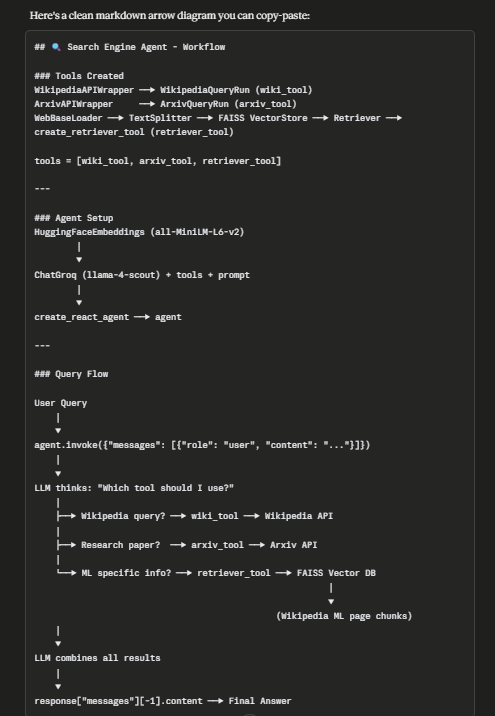

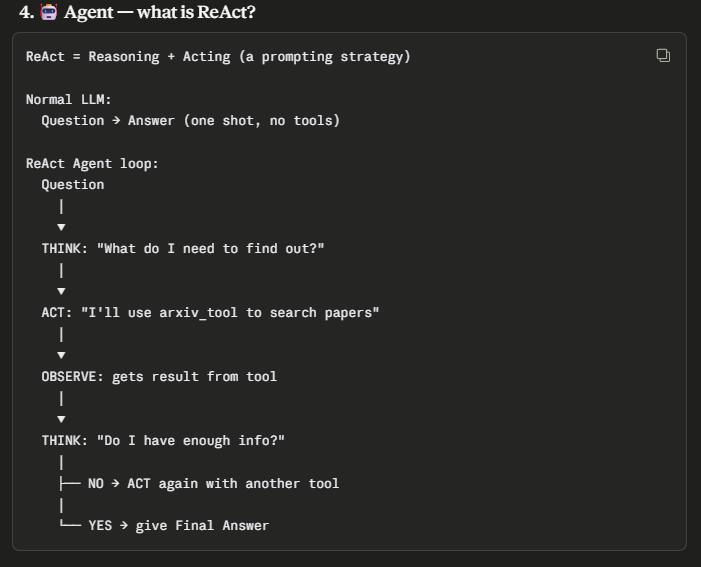

In [19]:
response2 = agent.invoke(
    {"messages" : [{"role" : "user" , "content" : "arXiv:1706.03762"}]}
)

print(response2["messages"][-1].content)

d:\Search Engine Langchain\gen_ai_search\Lib\site-packages\langchain_community\utilities\arxiv.py:102: DeprecationWarning: The 'Search.results' method is deprecated, use 'Client.results' instead
  ).results()
d:\Search Engine Langchain\gen_ai_search\Lib\site-packages\langchain_community\utilities\arxiv.py:105: DeprecationWarning: The 'Search.results' method is deprecated, use 'Client.results' instead
  ).results()


The paper titled "Attention Is All You Need" by Ashish Vaswani et al. introduces the Transformer model, which relies solely on attention mechanisms and does not use recurrent or convolutional neural networks. The model achieves state-of-the-art results in machine translation tasks, including a BLEU score of 28.4 on the WMT 2014 English-to-German translation task and 41.8 on the WMT 2014 English-to-French translation task. 

Would you like to know more about the Transformer model or its applications?
